In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

import arviz as az
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from chainconsumer import Chain, ChainConsumer, make_sample, PlotConfig, Truth, ChainConfig

/mnt/home/vpandya/miniconda3/envs/japphire/lib/python3.12/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
# filename for nuts -- first wildcard is for chain number 0-3, second for flag XYZ
fname_nuts = '/mnt/ceph/users/vpandya/sapphire_outputs/outputs/numpyro_mix_chain%s_%s_slope4_mzrgas_samples12K.npz'

# filename for aies -- wildcard is for flag
fname_aies = '/mnt/ceph/users/vpandya/sapphire_outputs_referee/outputs/aies20split_mix_%s.npz'


In [3]:
# global plotting options
params_free = ["A_M","alpha0_M","A_E","alpha0_E","A_SF","alpha0_SF","A_Z","alpha0_Z"]
flag_labels = {'100':r'SMHM','110':r'SMHM+f$_{\rm ISM}$','111':r'SMHM+f$_{\rm ISM}$+MZR'}
color_nuts = 'rose'
color_aies = 'blue'

In [8]:
### first plot AIES (all walkers in single file)
npz_aies = np.load(fname_aies%'100',allow_pickle=True)
samples_dict_aies = {k: npz_aies['samples'].item()[k] for k in params_free}
samples_df_aies = pd.DataFrame(samples_dict_aies)  

In [13]:
ptiles_aies = samples_df_aies.quantile([0.16, 0.50, 0.84]).T
ptiles_aies

,0.16,0.50,0.84
A_M,-1.069847,-0.454607,0.027017
alpha0_M,-3.441360,-2.566364,-1.394328
A_E,-0.497069,-0.441890,-0.393022
alpha0_E,-1.645221,-1.188432,-0.775628
A_SF,0.438274,0.645298,0.845713
alpha0_SF,-3.454449,-3.035547,-2.280060
A_Z,-1.529612,-0.983367,-0.435017
alpha0_Z,-2.961775,-1.836735,-0.797310


In [21]:
ptiles_aies.loc['A_M'].values

array([-1.06984684, -0.45460671,  0.0270174 ])

In [44]:
### adapt sapphire/visualization/numpyro_plots.py 

def multicorner(flag,fname_nuts,fname_aies):

    # initialize chainconsumer
    consumer = ChainConsumer()

    ### first plot AIES (all walkers in single file)
    npz_aies = np.load(fname_aies%flag,allow_pickle=True)
    samples_dict_aies = {k: npz_aies['samples'].item()[k] for k in params_free}
    samples_df_aies = pd.DataFrame(samples_dict_aies)    

    consumer.add_chain(Chain(samples=samples_df_aies, name='AIES',color=color_aies,shade_alpha=0.2))

    ### next plot NUTS (merging different chains from different files)
    chains_nuts = {} 
    
    for cnum in range(0,4):

        npz_nuts = np.load(fname_nuts%(cnum,flag),allow_pickle=True)
    
        samples_dict_nuts = {k: npz_nuts['samples'].item()[k] for k in params_free}
        samples_df_nuts = pd.DataFrame(samples_dict_nuts)
        chains_nuts[cnum] = samples_df_nuts

    samples_df_nuts = pd.concat(chains_nuts.values(), ignore_index=True) 

    consumer.add_chain(Chain(samples=samples_df_nuts, name='NUTS',color=color_nuts,shade_alpha=0.2))

    ### compute and plot lines for 16-50-84 percentiles for both sets of runs

    # medians
    consumer.add_truth(Truth(location=samples_df_aies.quantile(0.50).to_dict(), color=color_aies, 
                             line_style='-',line_width=2,alpha=0.5))
    consumer.add_truth(Truth(location=samples_df_nuts.quantile(0.50).to_dict(), color='indianred', 
                             line_style='-',line_width=2,alpha=0.5))    

    # 16th
    consumer.add_truth(Truth(location=samples_df_aies.quantile(0.16).to_dict(), color=color_aies, 
                             line_style='--',line_width=1,alpha=0.5))
    consumer.add_truth(Truth(location=samples_df_nuts.quantile(0.16).to_dict(), color='indianred', 
                             line_style='--',line_width=1,alpha=0.5))        

    # 84th 
    consumer.add_truth(Truth(location=samples_df_aies.quantile(0.84).to_dict(), color=color_aies, 
                             line_style='--',line_width=1,alpha=0.5))
    consumer.add_truth(Truth(location=samples_df_nuts.quantile(0.84).to_dict(), color='indianred', 
                             line_style='--',line_width=1,alpha=0.5))            

    
    # TO DO: generalize with user inputting these
    consumer.set_plot_config(PlotConfig(extents={'A_M':(-2.1,1.1),'alpha0_M':(-4.1,0.1),
                                                 'A_E':(-2.1,0.1),'alpha0_E':(-4.1,0.1),
                                                 'A_SF':(-0.1,1.2),'alpha0_SF':(-4.1,0.1),
                                                 'A_Z':(-2.1,0.1),'alpha0_Z':(-4.1,0.1),},
                                        labels={'A_M':r'$A_M$','alpha0_M':r'$\alpha_M^0$',
                                                'A_E':r'$A_E$','alpha0_E':r'$\alpha_E^0$',
                                                'A_SF':r'$A_{\rm SF}$','alpha0_SF':r'$\alpha_{\rm SF}^0$',
                                                'A_Z':r'$A_Z$','alpha0_Z':r'$\alpha_Z^0$'},
                                        label_font_size=16,
                                        legend_location=(0,0),legend_kwargs={'bbox_to_anchor':(3.5,1.0),'fontsize':30}))

    # create plot
    fig = consumer.plotter.plot()  
    axes = np.reshape(fig.axes,(8,8))  
    
    fig.suptitle(flag_labels[flag],fontsize=32,y=0.93)

    return fig

    
    

Parameter A_M in chain AIES is not constrained
Parameter A_M in chain NUTS is not constrained
Parameter A_SF in chain NUTS is not constrained
Parameter A_Z in chain AIES is not constrained
Parameter alpha0_Z in chain NUTS is not constrained


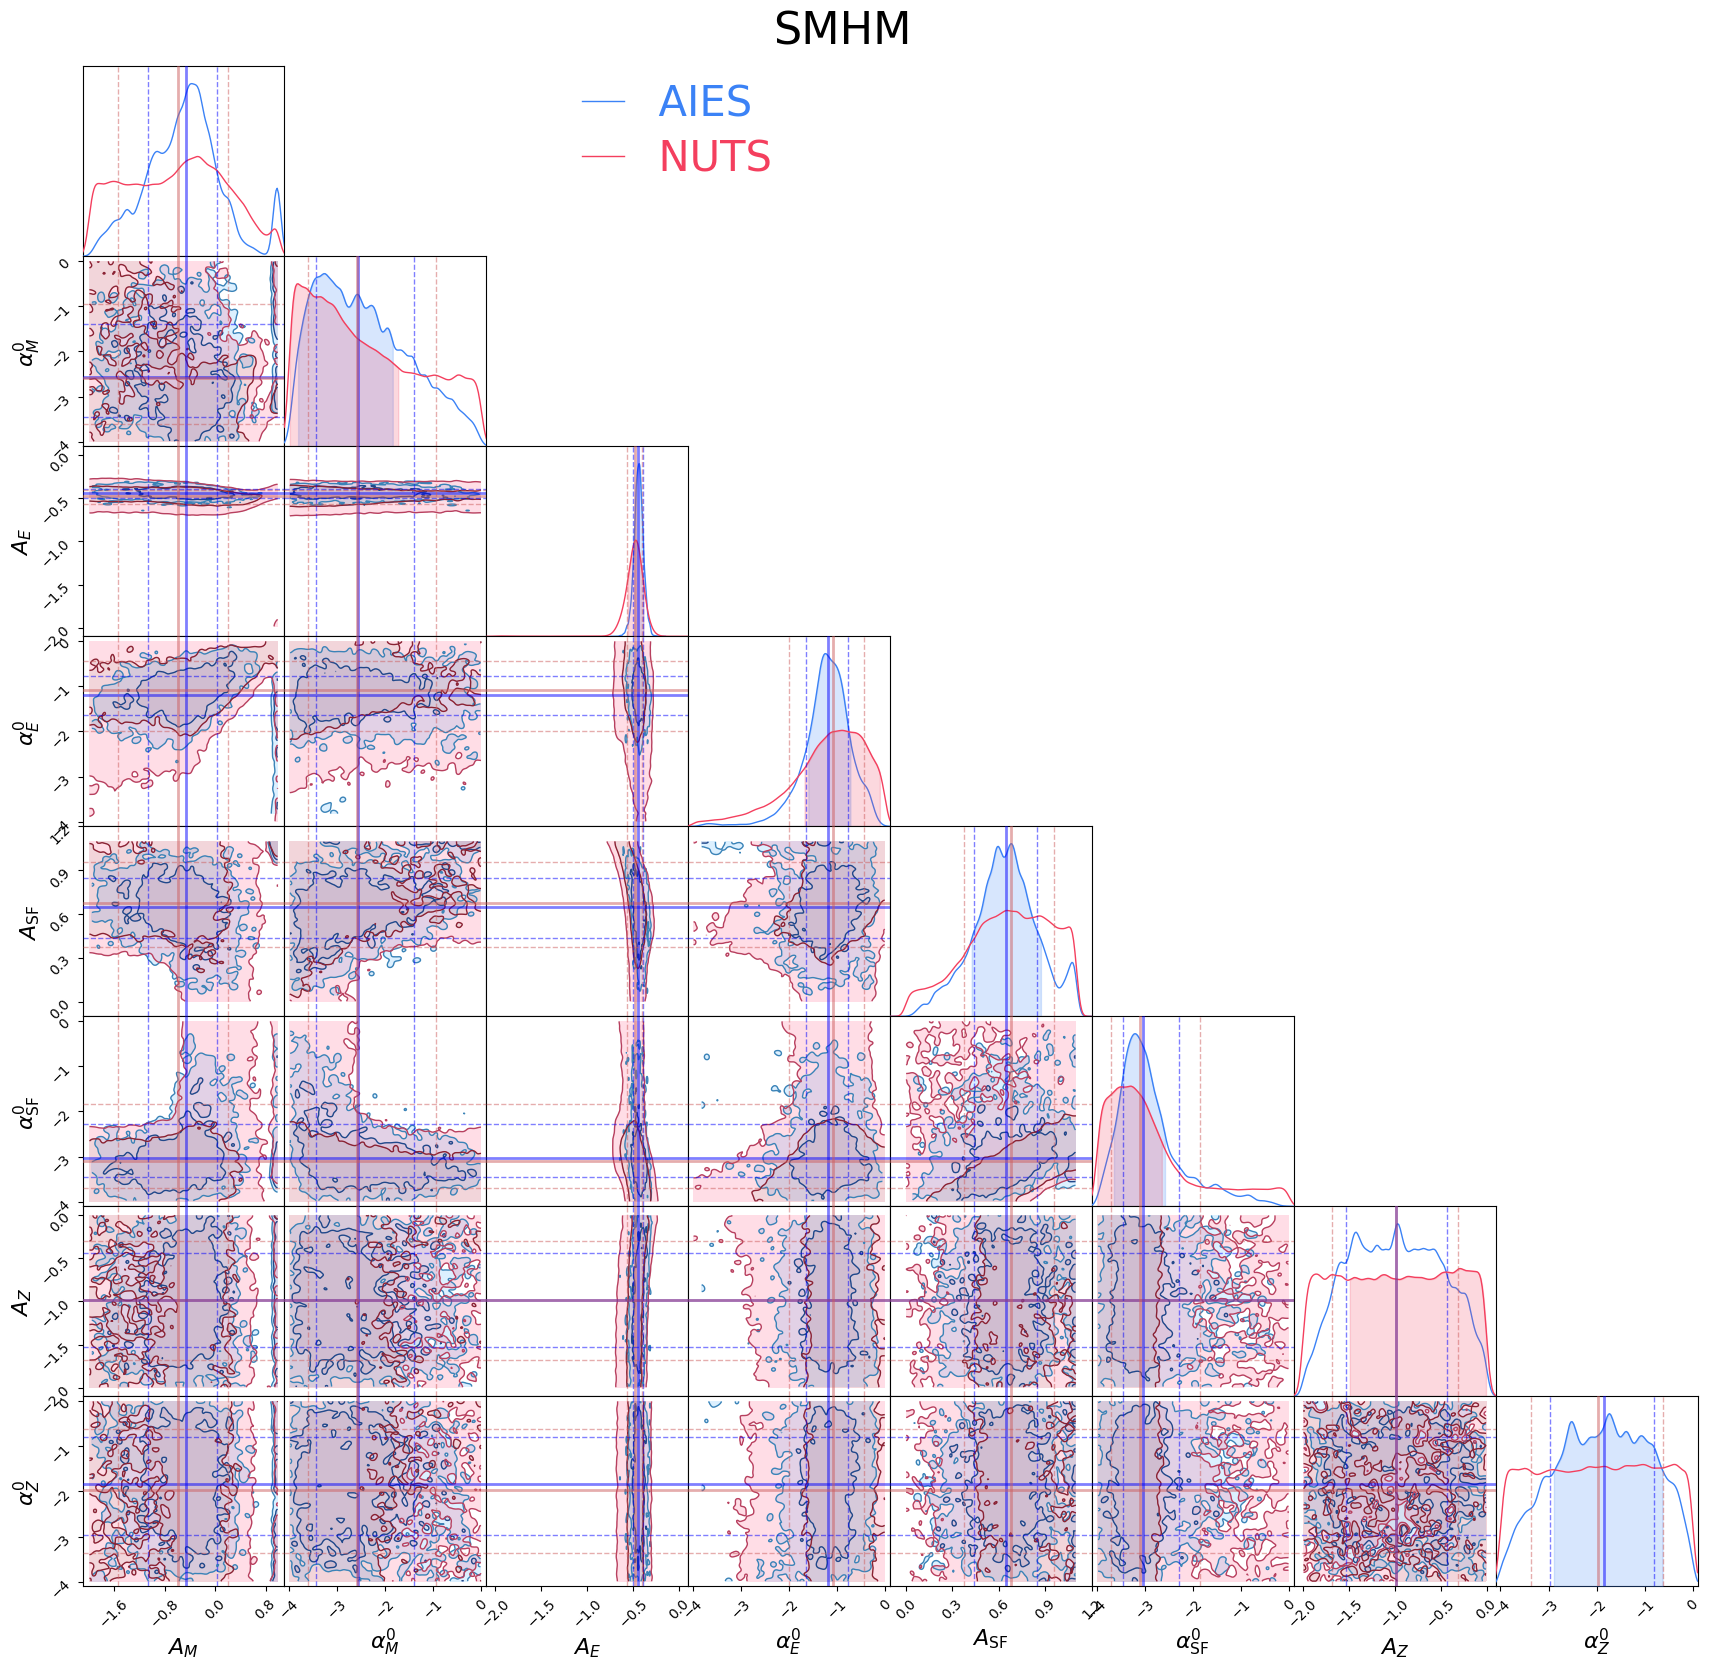

In [47]:
fig = multicorner('100',fname_nuts,fname_aies) 

# plt.savefig('compare_aies_nuts_100_withpercentiles.png',dpi=120,bbox_inches='tight',facecolor='w') 

Parameter A_M in chain AIES is not constrained
Parameter A_Z in chain AIES is not constrained
Parameter A_Z in chain NUTS is not constrained
Parameter alpha0_Z in chain NUTS is not constrained


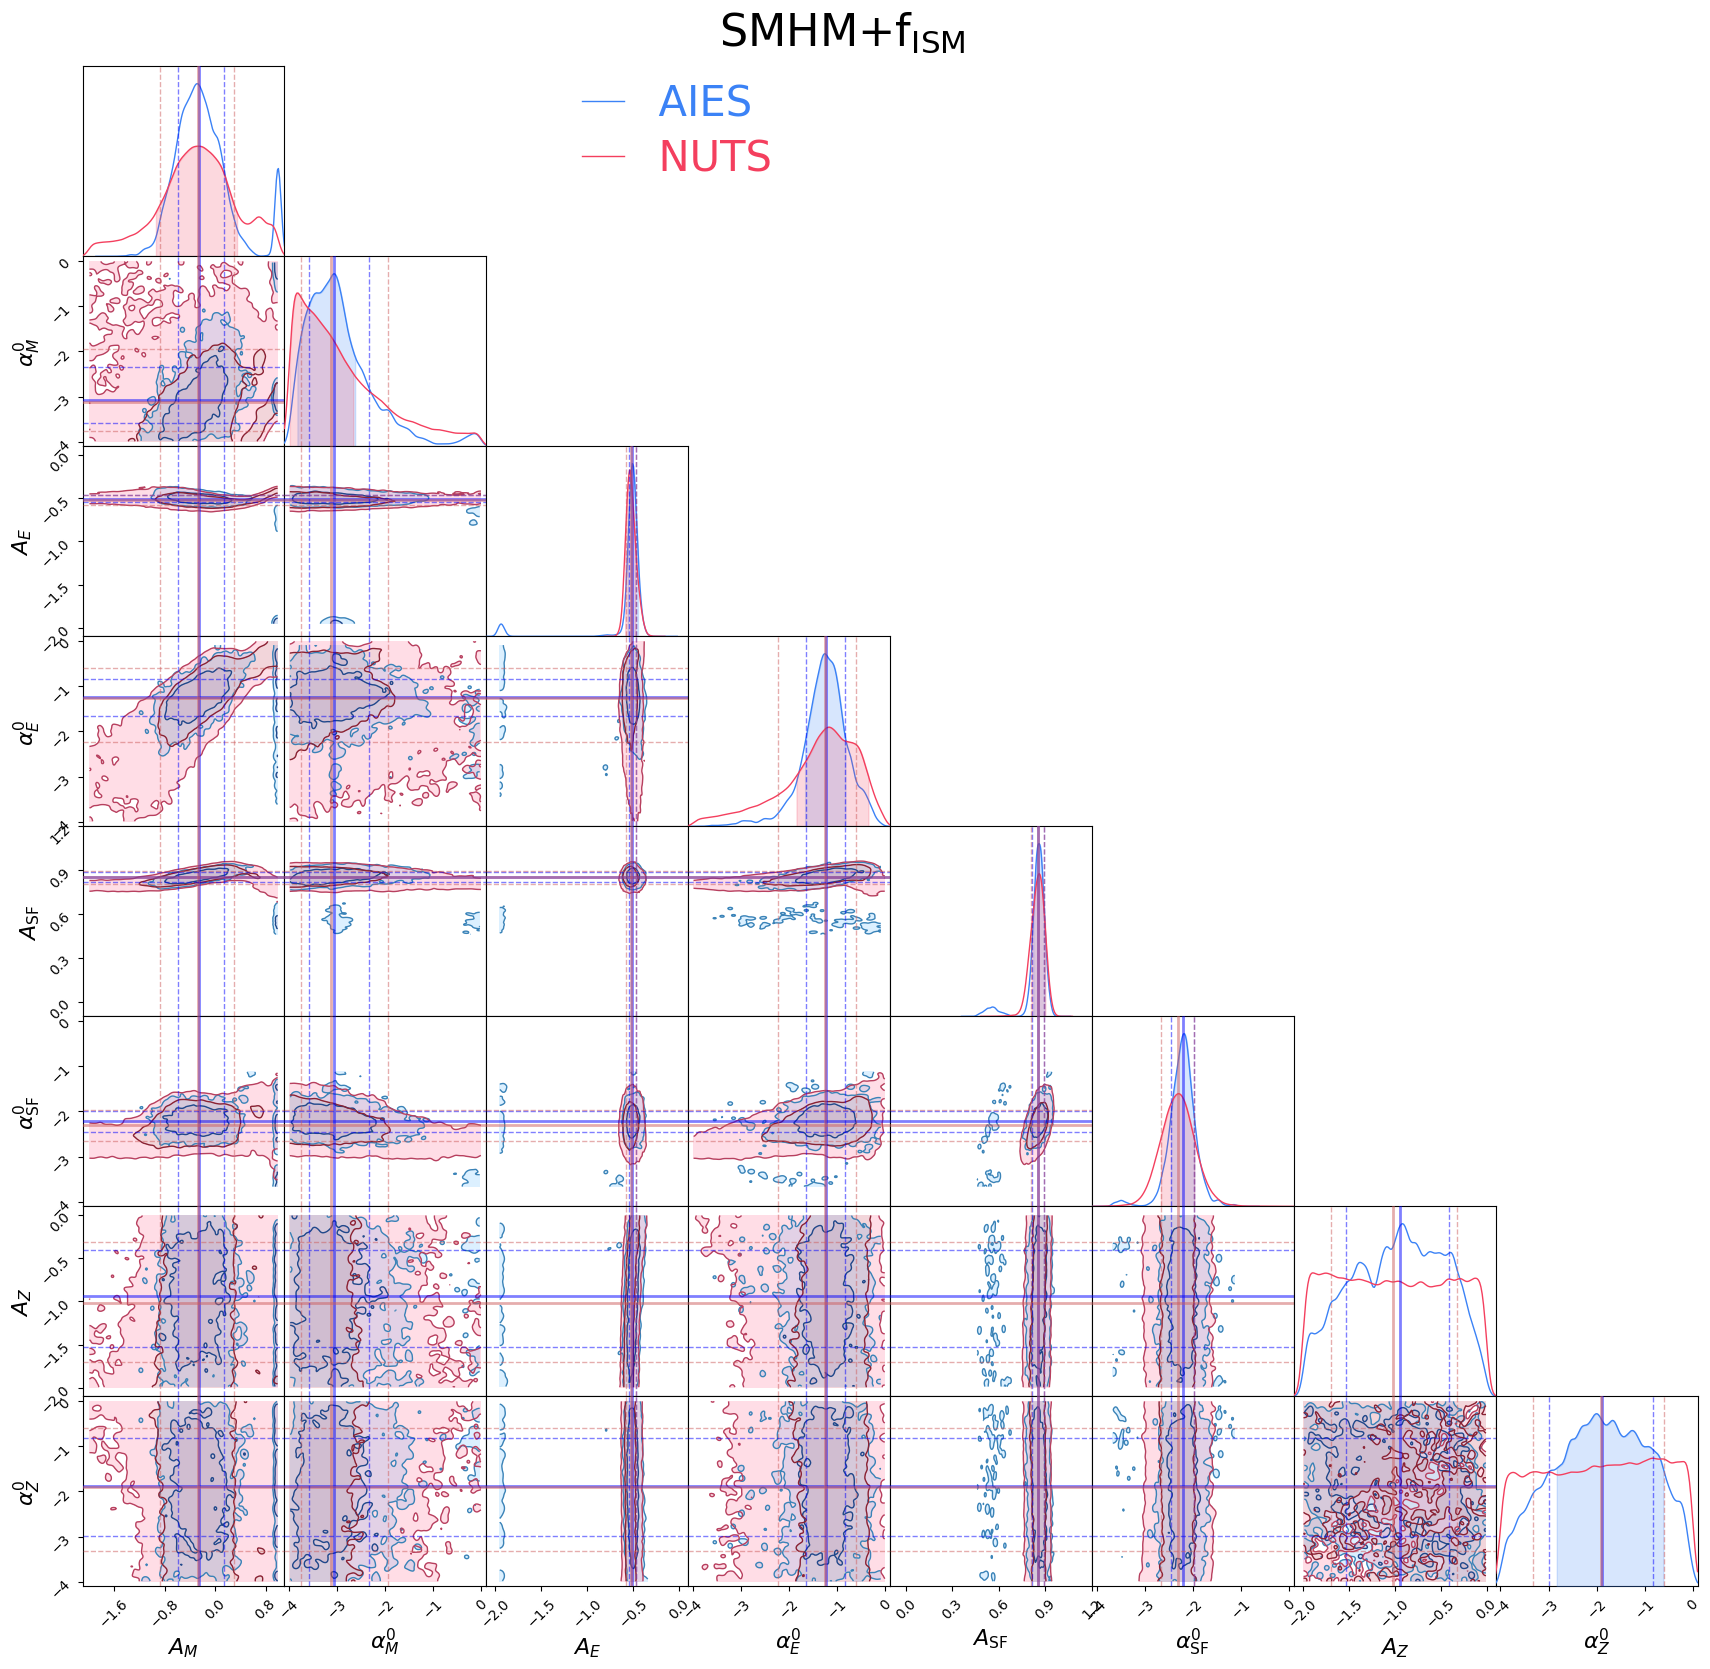

In [48]:
fig = multicorner('110',fname_nuts,fname_aies) 

# plt.savefig('compare_aies_nuts_110_withpercentiles.png',dpi=120,bbox_inches='tight',facecolor='w') 

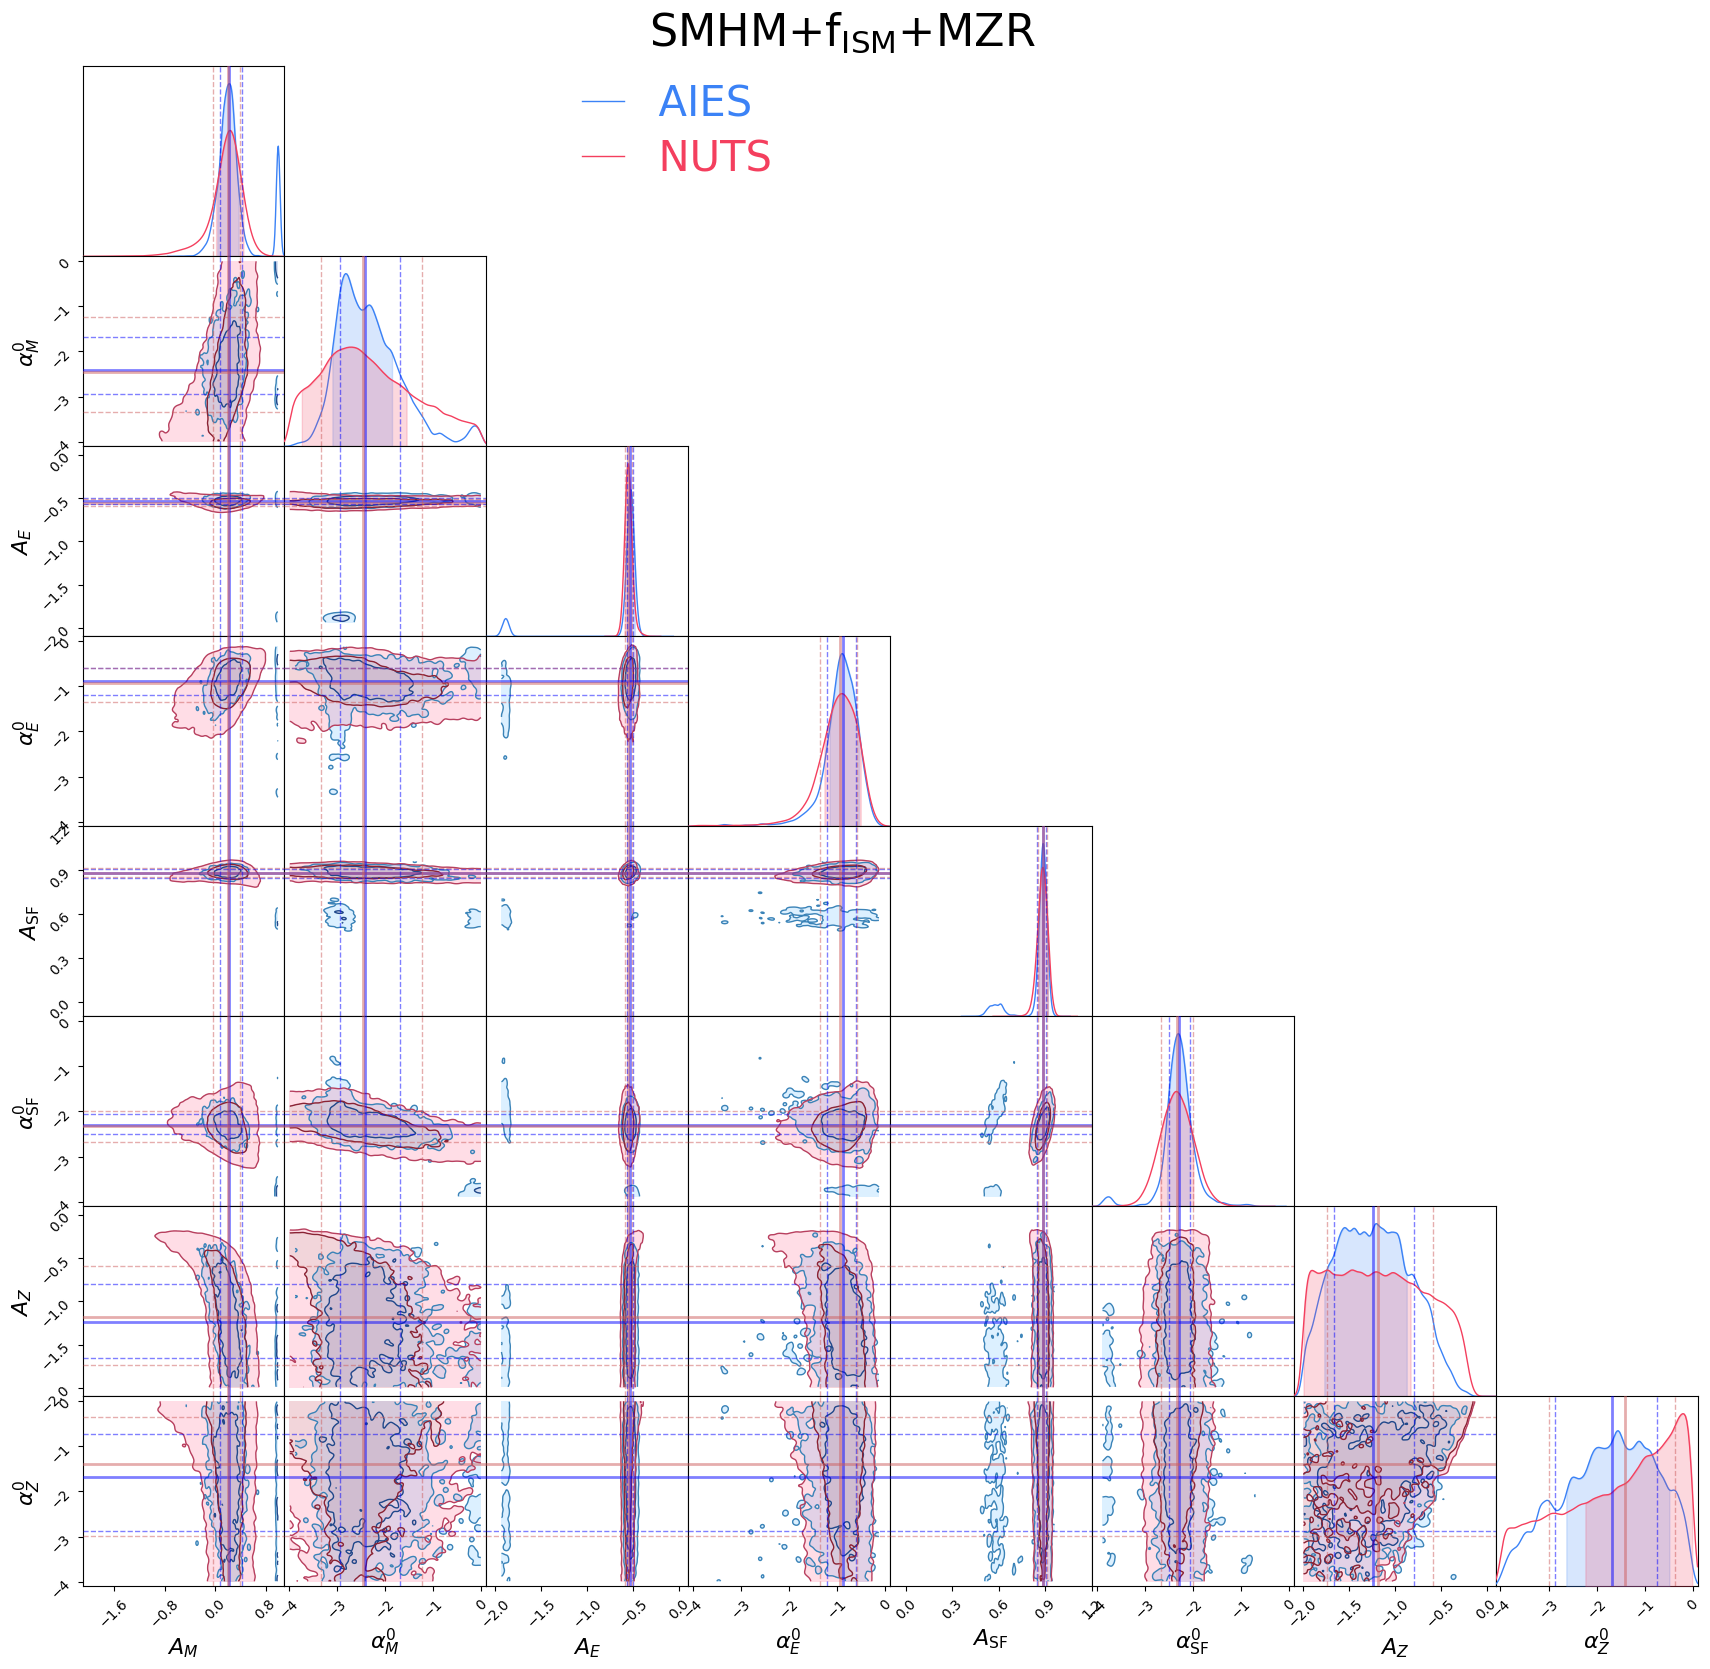

In [49]:
fig = multicorner('111',fname_nuts,fname_aies)

# plt.savefig('compare_aies_nuts_111_withpercentiles.png',dpi=120,bbox_inches='tight',facecolor='w') 